In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import mglearn
import numpy as np
from sklearn.model_selection import train_test_split

X.shape:(26, 2)


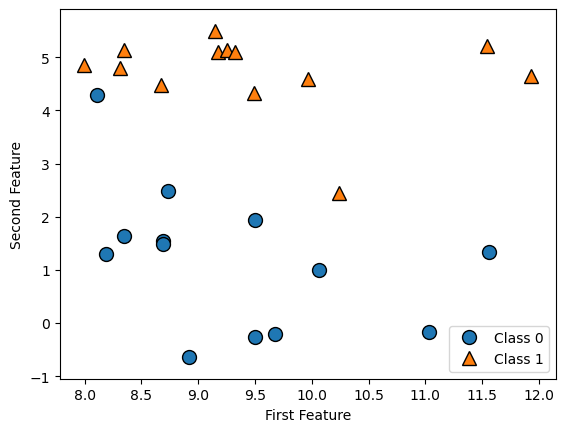

In [2]:
X,y = mglearn.datasets.make_forge()
mglearn.discrete_scatter(X[:,0],X[:,1],y)
plt.legend(["Class 0","Class 1"],loc=4)
plt.xlabel("First Feature")
plt.ylabel("Second Feature")
print(f"X.shape:{X.shape}")

Text(0, 0.5, 'Target')

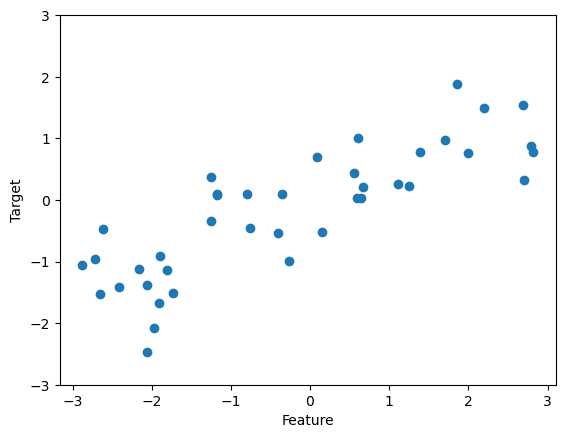

In [3]:
X,y = mglearn.datasets.make_wave(n_samples=40)
plt.plot(X,y,'o')
plt.ylim(-3,3)
plt.xlabel("Feature")
plt.ylabel("Target")

In [4]:
from sklearn.datasets import load_breast_cancer
cancer = load_breast_cancer()
print(f"cancer.keys():{cancer.keys()}")

cancer.keys():dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])


In [5]:
print(f"Shape of ccancer data:{cancer.data.shape}")

Shape of ccancer data:(569, 30)


In [6]:
counts = {n:v for n, v in zip(cancer.target_names,np.bincount(cancer.target))}
print(f"Sample counts per class: {counts}")

Sample counts per class: {np.str_('malignant'): np.int64(212), np.str_('benign'): np.int64(357)}


In [7]:
print(f"Feature names:{cancer.feature_names}")

Feature names:['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']


In [8]:
from sklearn.datasets import fetch_california_housing

# load_boston() の代わりに fetch_california_housing() を使います
california = fetch_california_housing()
print(f"Data shape {california.data.shape}")

Data shape (20640, 8)


In [9]:
from sklearn.datasets import fetch_california_housing
from sklearn.preprocessing import MinMaxScaler, PolynomialFeatures

# 1. カリフォルニアデータの読み込み
california = fetch_california_housing()
X, y = california.data, california.target

# 2. データの正規化（0〜1の範囲にスケーリング）
X_scaled = MinMaxScaler().fit_transform(X)

# 3. 特徴量の拡張（2乗項や特徴量同士の掛け合わせを作成）
poly = PolynomialFeatures(degree=2, include_bias=False)
X_extended_california = poly.fit_transform(X_scaled)

print(f"元の特徴量数: {X.shape[1]}")
print(f"拡張後の特徴量数: {X_extended_california.shape[1]}")

元の特徴量数: 8
拡張後の特徴量数: 44


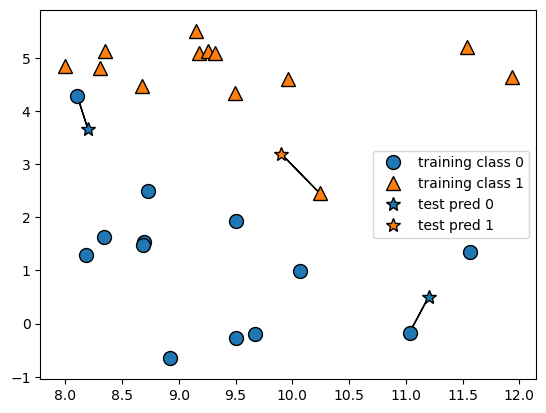

In [10]:
mglearn.plots.plot_knn_classification(n_neighbors=1)

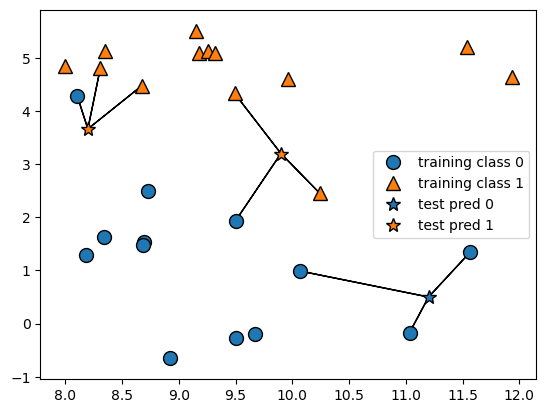

In [11]:
mglearn.plots.plot_knn_classification(n_neighbors=3)

In [12]:
from sklearn.model_selection import train_test_split
X,y = mglearn.datasets.make_forge()

X_train,X_test,y_train,y_test = train_test_split(X,y,random_state=0)

In [13]:
from sklearn.neighbors import KNeighborsClassifier
clf = KNeighborsClassifier(n_neighbors=3)

In [14]:
clf.fit(X_train,y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",3
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [15]:
print(f"Test set predictions:{clf.predict(X_test)}")

Test set predictions:[1 0 1 0 1 0 0]


In [16]:
print(f"Test set accuracy:{clf.score(X_test,y_test)}")

Test set accuracy:0.8571428571428571


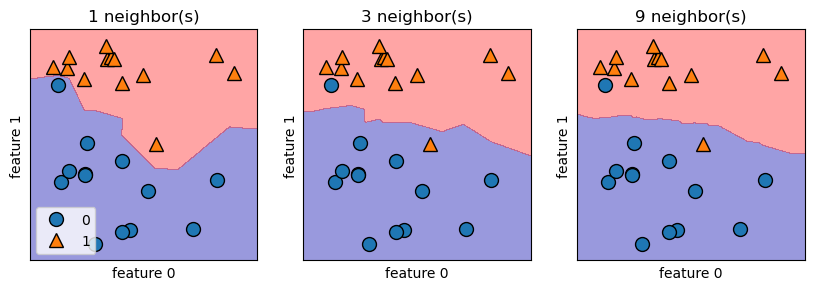

In [17]:
fig,axes = plt.subplots(1,3,figsize=(10,3))
for n_neighbors,ax in zip([1,3,9],axes):
    clf = KNeighborsClassifier(n_neighbors=n_neighbors).fit(X,y)
    mglearn.plots.plot_2d_separator(clf,X,fill=True,eps=0.5,ax=ax,alpha=.4)
    mglearn.discrete_scatter(X[:,0],X[:,1],y,ax=ax)
    ax.set_title(f"{n_neighbors} neighbor(s)")
    ax.set_xlabel("feature 0")
    ax.set_ylabel("feature 1")
axes[0].legend(loc=3)

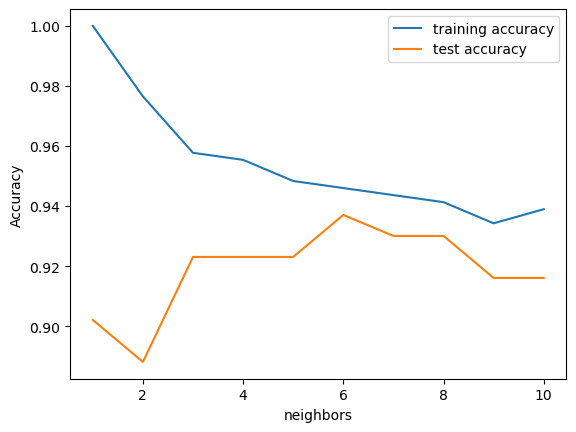

In [18]:
from sklearn.datasets import load_breast_cancer

cancer = load_breast_cancer()
X_train,X_test,y_train,y_test = train_test_split(cancer.data,cancer.target,stratify=cancer.target,random_state=66)

training_accuracy = []
test_accuracy = []
neighbors_settings = range(1,11)
for n_neighbors in neighbors_settings:
    clf = KNeighborsClassifier(n_neighbors=n_neighbors)
    clf.fit(X_train,y_train)
    training_accuracy.append(clf.score(X_train,y_train))
    test_accuracy.append(clf.score(X_test,y_test))
plt.plot(neighbors_settings,training_accuracy,label="training accuracy")
plt.plot(neighbors_settings,test_accuracy,label="test accuracy")
plt.ylabel("Accuracy")
plt.xlabel("neighbors")
plt.legend()

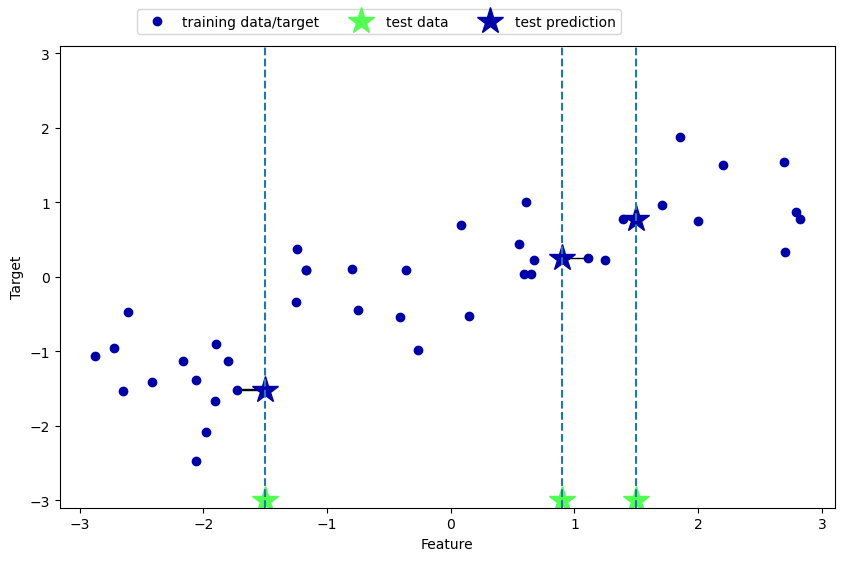

In [19]:
mglearn.plots.plot_knn_regression(n_neighbors=1)

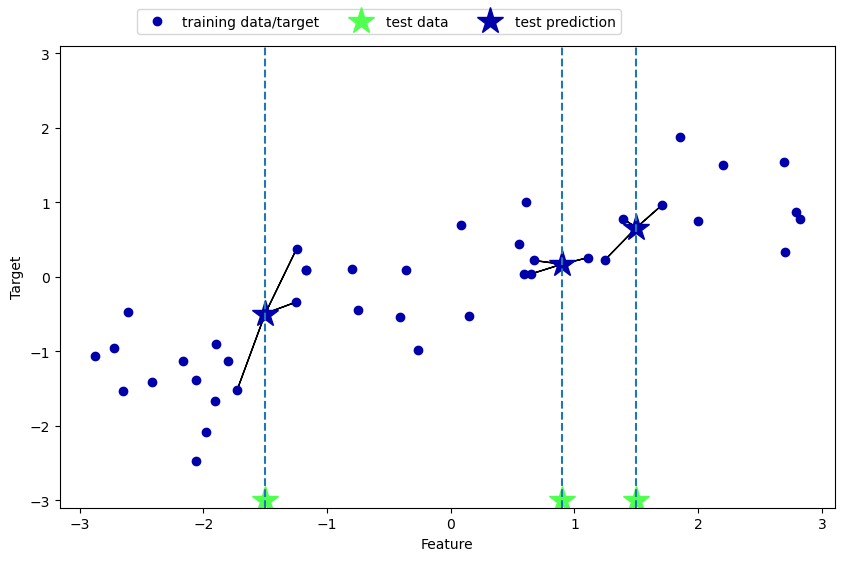

In [20]:
mglearn.plots.plot_knn_regression(n_neighbors=3)

In [21]:
from sklearn.neighbors import KNeighborsRegressor
X,y = mglearn.datasets.make_wave(n_samples=40)
X_train,X_test,y_train,y_test = train_test_split(X,y,random_state=0)
reg = KNeighborsRegressor(n_neighbors=3)
reg.fit(X_train,y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",3
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Uniform weights are used by default.See the following example for a demonstration of the impact ofdifferent weighting schemes on predictions::ref:`sphx_glr_auto_examples_neighbors_plot_regression.py`.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric metric: str, DistanceMetric object or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.If metric is a DistanceMetric object, it will be passed directly tothe underlying computation routines.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [22]:
print(f"Test set predictions:{reg.predict(X_test)}")

Test set predictions:[-0.05396539  0.35686046  1.13671923 -1.89415682 -1.13881398 -1.63113382
  0.35686046  0.91241374 -0.44680446 -1.13881398]


In [23]:
print(f"Test set score:{reg.score(X_test,y_test)}")

Test set score:0.8344172446249605


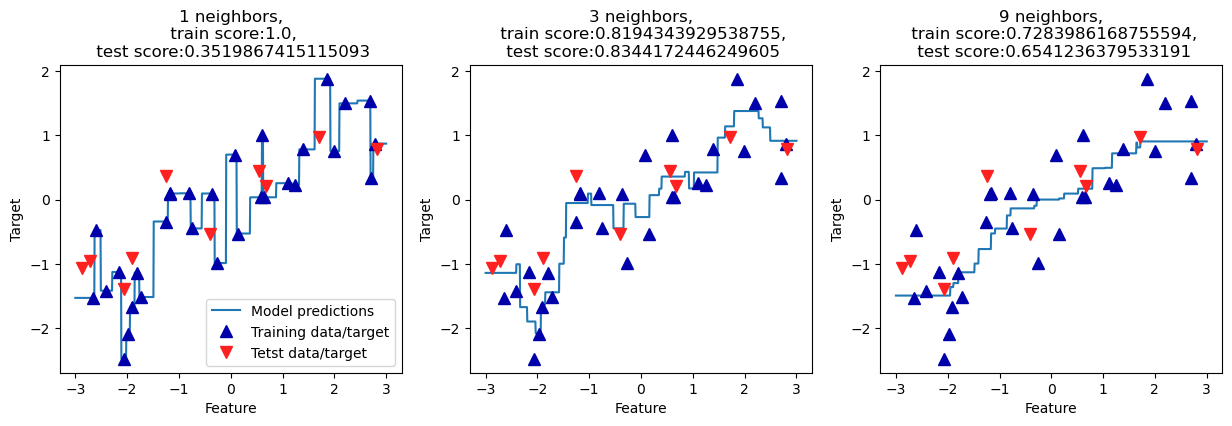

In [24]:
fig,axes = plt.subplots(1,3,figsize=(15,4))
line = np.linspace(-3,3,1000).reshape(-1,1)
for n_neighbors,ax in zip([1,3,9],axes):
    reg = KNeighborsRegressor(n_neighbors=n_neighbors)
    reg.fit(X_train,y_train)
    ax.plot(line,reg.predict(line))
    ax.plot(X_train,y_train,'^',color=mglearn.cm2(0),markersize=8)
    ax.plot(X_test,y_test,'v',color=mglearn.cm2(1),markersize=8)
    ax.set_title(f"{n_neighbors} neighbors,\n train score:{reg.score(X_train,y_train)},\n test score:{reg.score(X_test,y_test)}")
    ax.set_xlabel("Feature")
    ax.set_ylabel("Target")
    axes[0].legend(["Model predictions","Training data/target","Tetst data/target"],loc="best")

w[0]: 0.393906  b: -0.031804


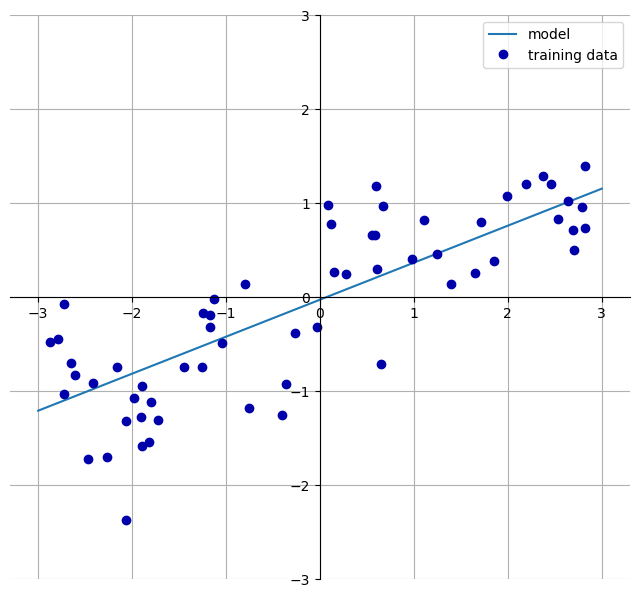

In [25]:
mglearn.plots.plot_linear_regression_wave()

In [26]:
from sklearn.linear_model import LinearRegression
X,y = mglearn.datasets.make_wave(n_samples=60)
X_train,X_test,y_train,y_test = train_test_split(X,y,random_state=42)
lr = LinearRegression().fit(X_train,y_train)

In [27]:
print(f"lr.coef_:{lr.coef_}")
print(f"lr.intercept_:{lr.intercept_}")

lr.coef_:[0.39390555]
lr.intercept_:-0.03180434302675973


In [28]:
print(f"Training set score:{lr.score(X_train,y_train)}")
print(f"Test set score:{lr.score(X_test,y_test)}")

Training set score:0.6700890315075756
Test set score:0.6593368596863701


In [29]:
from sklearn.datasets import fetch_california_housing
from sklearn.preprocessing import MinMaxScaler, PolynomialFeatures

# 1. カリフォルニアデータの読み込み
california = fetch_california_housing()
X, y = california.data, california.target

# 2. データの正規化（0〜1の範囲にスケーリング）
X_scaled = MinMaxScaler().fit_transform(X)

# 3. 特徴量の拡張（2乗項や特徴量同士の掛け合わせを作成）
poly = PolynomialFeatures(degree=2, include_bias=False)
X_extended_california = poly.fit_transform(X_scaled)

X,y = X_extended_california,y

X_train,X_test,y_train,y_test = train_test_split(X,y,random_state=0)
lr = LinearRegression().fit(X_train,y_train)

In [31]:
print(f"Training set score:{lr.score(X_train,y_train)}")
print(f"Tetst score:{lr.score(X_test,y_test)}")

Training set score:0.6859342166230965
Tetst score:-0.7296138888213979


In [32]:
from sklearn.linear_model import Ridge
ridge = Ridge().fit(X_train,y_train)
print(f"Training set score:{ridge.score(X_train,y_train)}")
print(f"Tetst score:{ridge.score(X_test,y_test)}")

Training set score:0.6264473905922332
Tetst score:0.6082724341793398


In [33]:
ridge10 = Ridge(alpha=10).fit(X_train,y_train)
print(f"Training set score:{ridge10.score(X_train,y_train)}")
print(f"Tetst score:{ridge10.score(X_test,y_test)}")

Training set score:0.6081878403418599
Tetst score:0.5853167083411199


In [34]:
ridge01 = Ridge(alpha=0.1).fit(X_train,y_train)
print(f"Training set score:{ridge01.score(X_train,y_train)}")
print(f"Tetst score:{ridge01.score(X_test,y_test)}")

Training set score:0.6457691215129189
Tetst score:0.6286192931794674


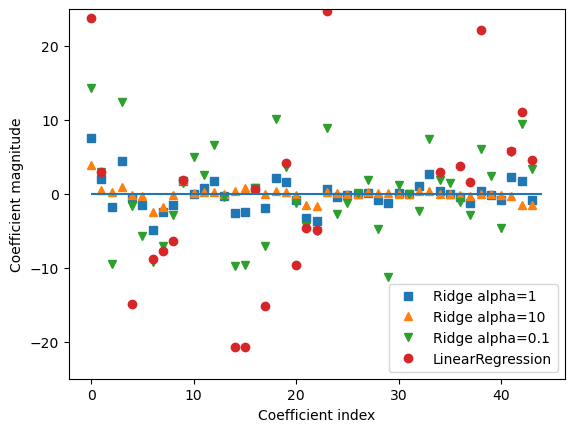

In [35]:
plt.plot(ridge.coef_,'s',label="Ridge alpha=1")
plt.plot(ridge10.coef_,'^',label="Ridge alpha=10")
plt.plot(ridge01.coef_,'v',label="Ridge alpha=0.1")
plt.plot(lr.coef_,'o',label="LinearRegression")
plt.xlabel("Coefficient index")
plt.ylabel('Coefficient magnitude')
plt.hlines(0,0,len(lr.coef_))
plt.ylim(-25,25)
plt.legend()

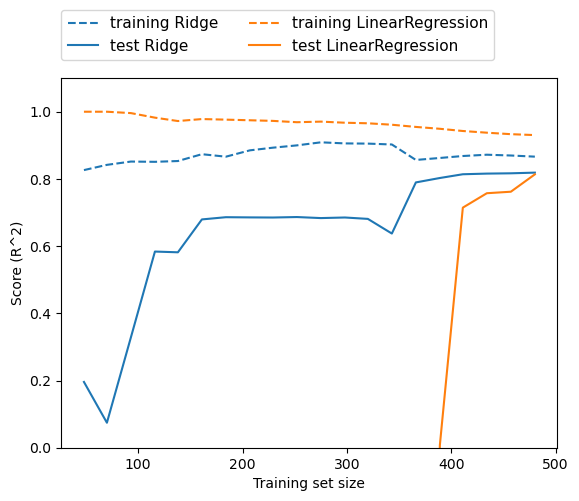

In [38]:
mglearn.plots.plot_ridge_n_samples()

In [40]:
from sklearn.linear_model import Lasso
lasso = Lasso().fit(X_train,y_train)
print(f"Training set score:{lasso.score(X_train,y_train)}")
print(f"Test set score:{lasso.score(X_test,y_test)}")
print(f"Number of features used:{np.sum(lasso.coef_ != 0)}")

Training set score:0.0
Test set score:-0.0004092193772518016
Number of features used:0


In [41]:
from sklearn.linear_model import Lasso
lasso001 = Lasso(alpha=0.01,max_iter = 100000).fit(X_train,y_train)
print(f"Training set score:{lasso001.score(X_train,y_train)}")
print(f"Test set score:{lasso001.score(X_test,y_test)}")
print(f"Number of features used:{np.sum(lasso001.coef_ != 0)}")

Training set score:0.5562169056762745
Test set score:0.5317229402994341
Number of features used:4


In [42]:
from sklearn.linear_model import Lasso
lasso00001 = Lasso(alpha=0.0001,max_iter = 100000).fit(X_train,y_train)
print(f"Training set score:{lasso00001.score(X_train,y_train)}")
print(f"Test set score:{lasso00001.score(X_test,y_test)}")
print(f"Number of features used:{np.sum(lasso00001.coef_ != 0)}")

Training set score:0.6368414962782822
Test set score:0.6217806949241769
Number of features used:19


Text(0, 0.5, 'Coefficient magnitude')

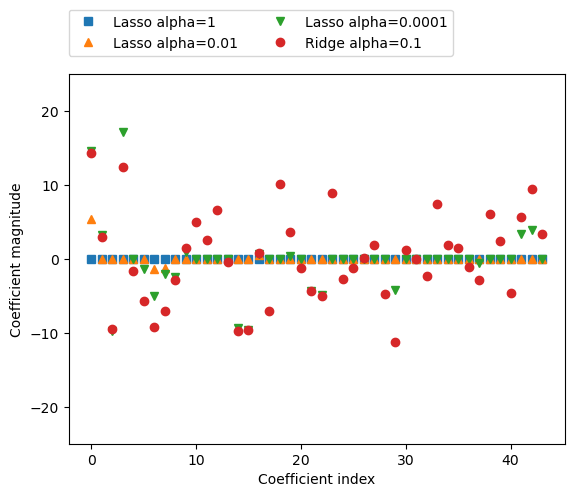

In [43]:
plt.plot(lasso.coef_,'s',label="Lasso alpha=1")
plt.plot(lasso001.coef_,'^',label="Lasso alpha=0.01")
plt.plot(lasso00001.coef_,'v',label="Lasso alpha=0.0001")
plt.plot(ridge01.coef_,'o',label="Ridge alpha=0.1")
plt.legend(ncol=2,loc=(0,1.05))
plt.ylim(-25,25)
plt.xlabel("Coefficient index")
plt.ylabel("Coefficient magnitude")

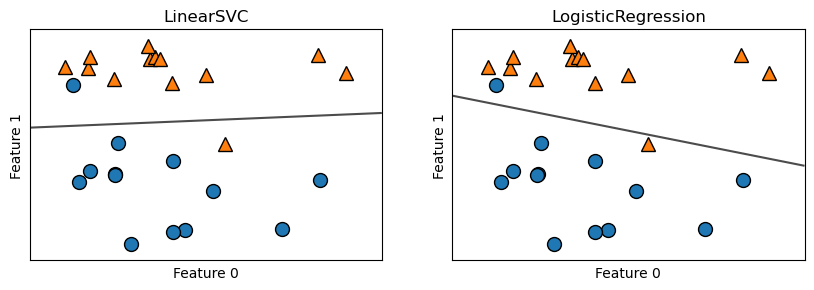

In [47]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
X,y = mglearn.datasets.make_forge()
fig,axes = plt.subplots(1,2,figsize=(10,3))
for model,ax in zip([LinearSVC(),LogisticRegression()],axes):
    clf = model.fit(X,y)
    mglearn.plots.plot_2d_separator(clf,X,fill=False,eps=0.5,ax=ax,alpha=0.7)
    mglearn.discrete_scatter(X[:,0],X[:,1],y,ax=ax)
    ax.set_title(f"{clf.__class__.__name__}")
    ax.set_xlabel("Feature 0")
    ax.set_ylabel("Feature 1")

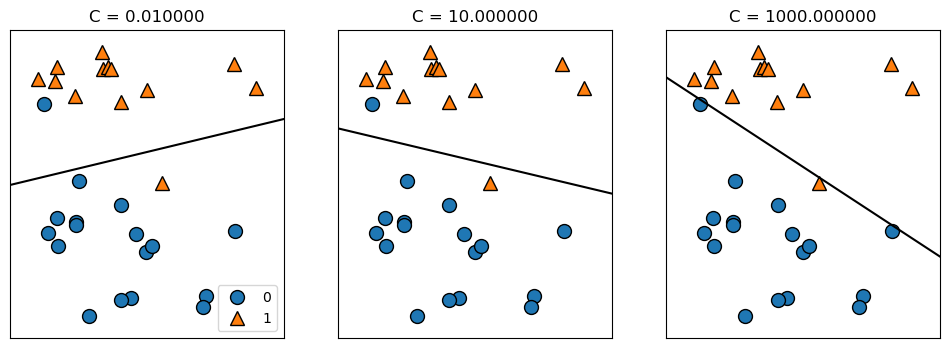

In [2]:
mglearn.plots.plot_linear_svc_regularization()

In [3]:
from sklearn.datasets import load_breast_cancer
cancer = load_breast_cancer()
X_train,X_test,y_train,y_test = train_test_split(cancer.data,cancer.target,stratify = cancer.target,random_state=42)
logreg = LogisticRegression(max_iter = 1000000).fit(X_train,y_train)
print(f"Training set score:{logreg.score(X_train,y_train)}")
print(f"Test set score:{logreg.score(X_test,y_test)}")

NameError: name 'LogisticRegression' is not defined

In [4]:
logreg100 = LogisticRegression(C=100,max_iter=1000000).fit(X_train,y_train)
print(f"Training set score:{logreg100.score(X_train,y_train)}")
print(f"Test set score:{logreg100.score(X_test,y_test)}")

NameError: name 'LogisticRegression' is not defined

In [5]:
logreg001 = LogisticRegression(C=0.01,max_iter=1000000).fit(X_train,y_train)
print(f"Training set score:{logreg001.score(X_train,y_train)}")
print(f"Test set score:{logreg001.score(X_test,y_test)}")

NameError: name 'LogisticRegression' is not defined

In [6]:
plt.plot(logreg.coef_.T,'o',label="C=1")
plt.plot(logreg100.coef_.T,'o',label="C=100")
plt.plot(logreg001.coef_.T,'o',label="C=0.01")
plt.xticks(range(cancer.data.shape[1]),cancer.feature_names,rotation=90)
plt.hlines(0,0,cancer.data.shape[1])
plt.ylim(-5,5)
plt.xlabel("Feature")
plt.ylabel("Coefficient magnitude")
plt.legend()

NameError: name 'logreg' is not defined

In [7]:
for C,marker in zip([0.001,1,100],['o','^','v']):
    lr_l1 = LogisticRegression(C=C,penalty="l2").fit(X_train,y_train)
    print(f"Training accuracy of l1 logreg with {C}:{lr_l1.score(X_train,y_train)}")
    print(f"Test accuracy of l1 logreg with {C}:{lr_l1.score(X_test,y_test)}")
    plt.plot(lr_l1.coef_.T,marker,label=C)
plt.xticks(range(cancer.data.shape[1]),cancer.feature_names,rotation=90)
plt.hlines(0,0,cancer.data.shape[1])
plt.xlabel("Feature")
plt.ylabel("Coefficient magnitude")
plt.ylim(-5,5)
plt.legend(loc=3)

NameError: name 'LogisticRegression' is not defined

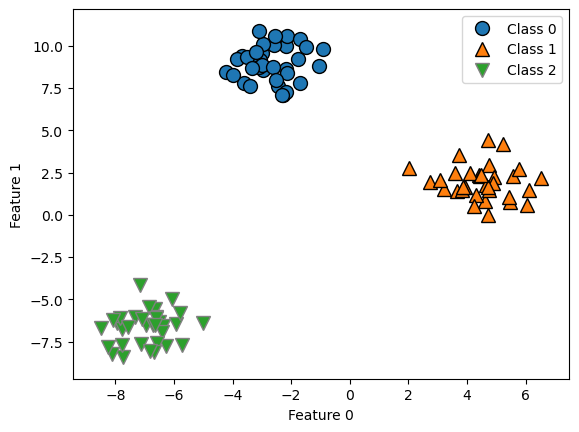

In [8]:
from sklearn.datasets import make_blobs
X,y = make_blobs(random_state=42)
mglearn.discrete_scatter(X[:,0],X[:,1],y)
plt.xlabel("Feature 0")
plt.ylabel("Feature 1")
plt.legend(["Class 0","Class 1","Class 2"])

In [9]:
linear_svm = LinearSVC().fit(X,y)
print("Coefficient shape:",linear_svm.coef_.shape)
print("Intercept shape:",linear_svm.intercept_.shape)

NameError: name 'LinearSVC' is not defined

In [ ]:
mglearn.discrete_scatter(X[:,0],X[:,1],y)
line = np.linspace(-15,15)
for coef,intercept,color in zip(linear_svm.coef_,linear_svm.intercept_,['b','r','g']):
    plt.plot(line,-(line*coef[0] + intercept) / coef[1],c=color)
plt.ylim(-10,15)
plt.xlim(-10,8)
plt.xlabel("Feature 0")
plt.ylabel("Feature 1")
plt.legend(["Class 0","Class 1","Class 2","Line Class 0","Line Class 1","Line Class 2"],loc=(1.01,0.3))

In [ ]:
mglearn.plots.plot_2d_classification(linear_svm,X,fill=True,alpha=0.7)
mglearn.discrete_scatter(X[:,0],X[:,1],y)
line = np.linspace(-15,15)
for coef,intercept,color in zip(linear_svm.coef_,linear_svm.intercept_,['b','r','g']):
    plt.plot(line,-(line*coef[0] + intercept) / coef[1],c=color)
plt.legend(["Class 0","Class 1","Class 2","Line Class 0","Line Class 1","Line Class 2"],loc=(1.01,0.3))
plt.xlabel("Feature 0")
plt.ylabel("Feature 1")

In [10]:
from sklearn.tree import DecisionTreeClassifier
cancer = load_breast_cancer()
X_train,X_test,y_train,y_test = train_test_split(cancer.data,cancer.target,stratify=cancer.target,random_state=42)
tree = DecisionTreeClassifier(random_state=0)
tree.fit(X_train,y_train)
print(f"Accuracy on training set:{tree.score(X_train,y_train)}")
print(f"Accuracy on test set:{tree.score(X_test,y_test)}")

Accuracy on training set:1.0
Accuracy on test set:0.9370629370629371


In [11]:
from sklearn.tree import export_graphviz
export_graphviz(tree,out_file="tree.dot",class_names=["malignant","benign"],feature_names=cancer.feature_names,impurity=False,filled=True)

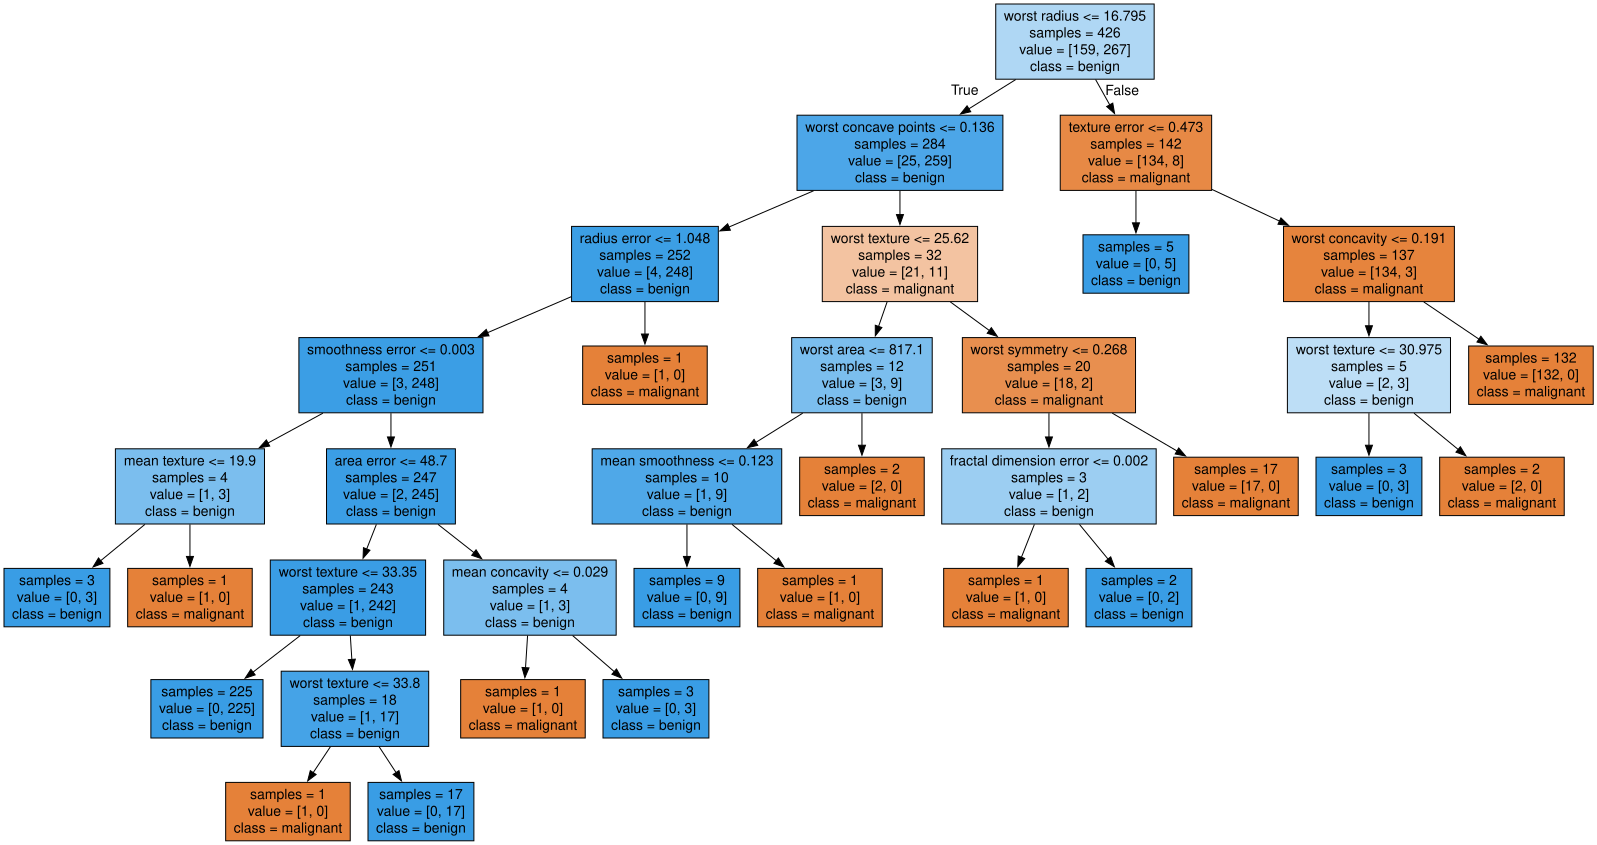

In [12]:
import graphviz
with open("tree.dot") as f:
    dot_graph = f.read()
graphviz.Source(dot_graph)

In [13]:
print(f"Feature importances: \n {tree.feature_importances_}")

Feature importances: 
 [0.         0.00752597 0.         0.         0.00903116 0.
 0.00752597 0.         0.         0.         0.00975731 0.04630969
 0.         0.00238745 0.00231135 0.         0.         0.
 0.         0.00668975 0.69546322 0.05383211 0.         0.01354675
 0.         0.         0.01740312 0.11684357 0.01137258 0.        ]


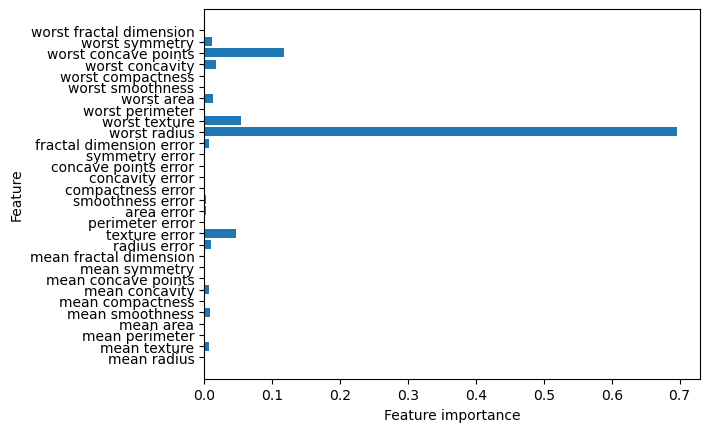

In [14]:
def plot_feature_importances_cancer(model):
    n_features = cancer.data.shape[1]
    plt.barh(range(n_features),model.feature_importances_,align='center')
    plt.yticks(np.arange(n_features),cancer.feature_names)
    plt.xlabel("Feature importance")
    plt.ylabel("Feature")
plot_feature_importances_cancer(tree)

Feature importances: [0. 1.]


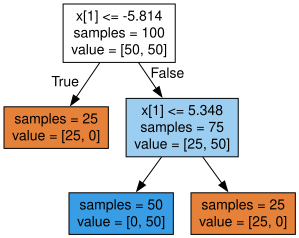

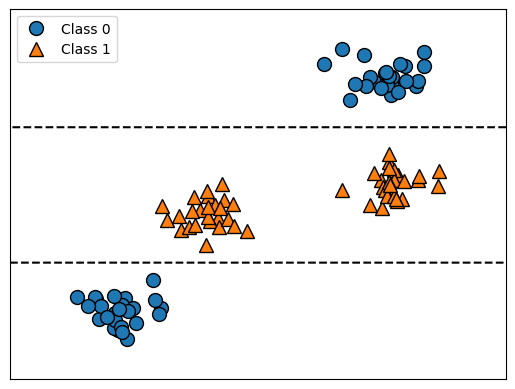

In [15]:
tree = mglearn.plots.plot_tree_not_monotone()
display(tree)

Text(0, 0.5, 'Price in byte')

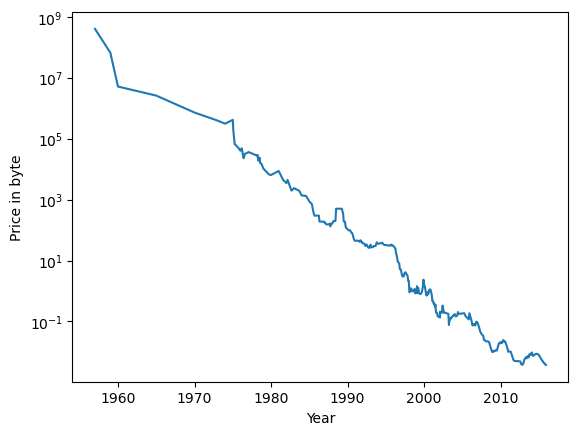

In [16]:
import os
ram_prices = pd.read_csv(os.path.join(mglearn.datasets.DATA_PATH,"ram_price.csv"))
plt.semilogy(ram_prices.date,ram_prices.price)
plt.xlabel("Year")
plt.ylabel("Price in byte")

In [17]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression
data_train = ram_prices[ram_prices.date < 2000]
data_test = ram_prices[ram_prices.date >= 2000]

# 二重ブラケットで 2 次元化して抽出
X_train = data_train[['date']]
y_train = np.log(data_train.price)

tree = DecisionTreeRegressor().fit(X_train, y_train)
linear_reg = LinearRegression().fit(X_train,y_train)

X_all = ram_prices.date.to_numpy()[:, np.newaxis]
pred_tree = tree.predict(X_all)
pred_lr = linear_reg.predict(X_all)
price_tree = np.exp(pred_tree)
price_lr = np.exp(pred_lr)

C:\Users\youta\miniconda3\envs\ml-study\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(
C:\Users\youta\miniconda3\envs\ml-study\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


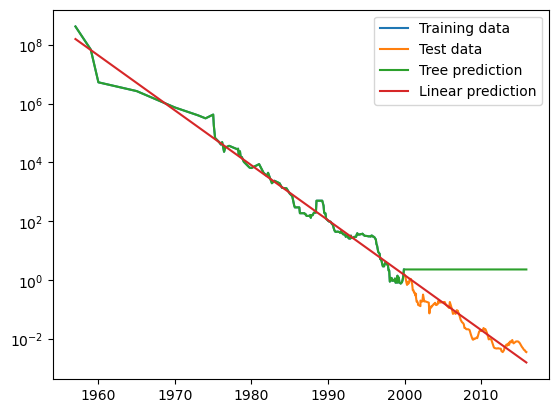

In [18]:
plt.semilogy(data_train.date,data_train.price,label="Training data")
plt.semilogy(data_test.date,data_test.price,label="Test data")
plt.semilogy(ram_prices.date,price_tree,label="Tree prediction")
plt.semilogy(ram_prices.date,price_lr,label="Linear prediction")
plt.legend()

In [19]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import make_moons
X,y = make_moons(n_samples=100,noise=0.25,random_state=3)
X_train,X_test,y_train,y_test = train_test_split(X,y,stratify=y,random_state=42)
forest = RandomForestClassifier(n_estimators=5,random_state=2)
forest.fit(X_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",5
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

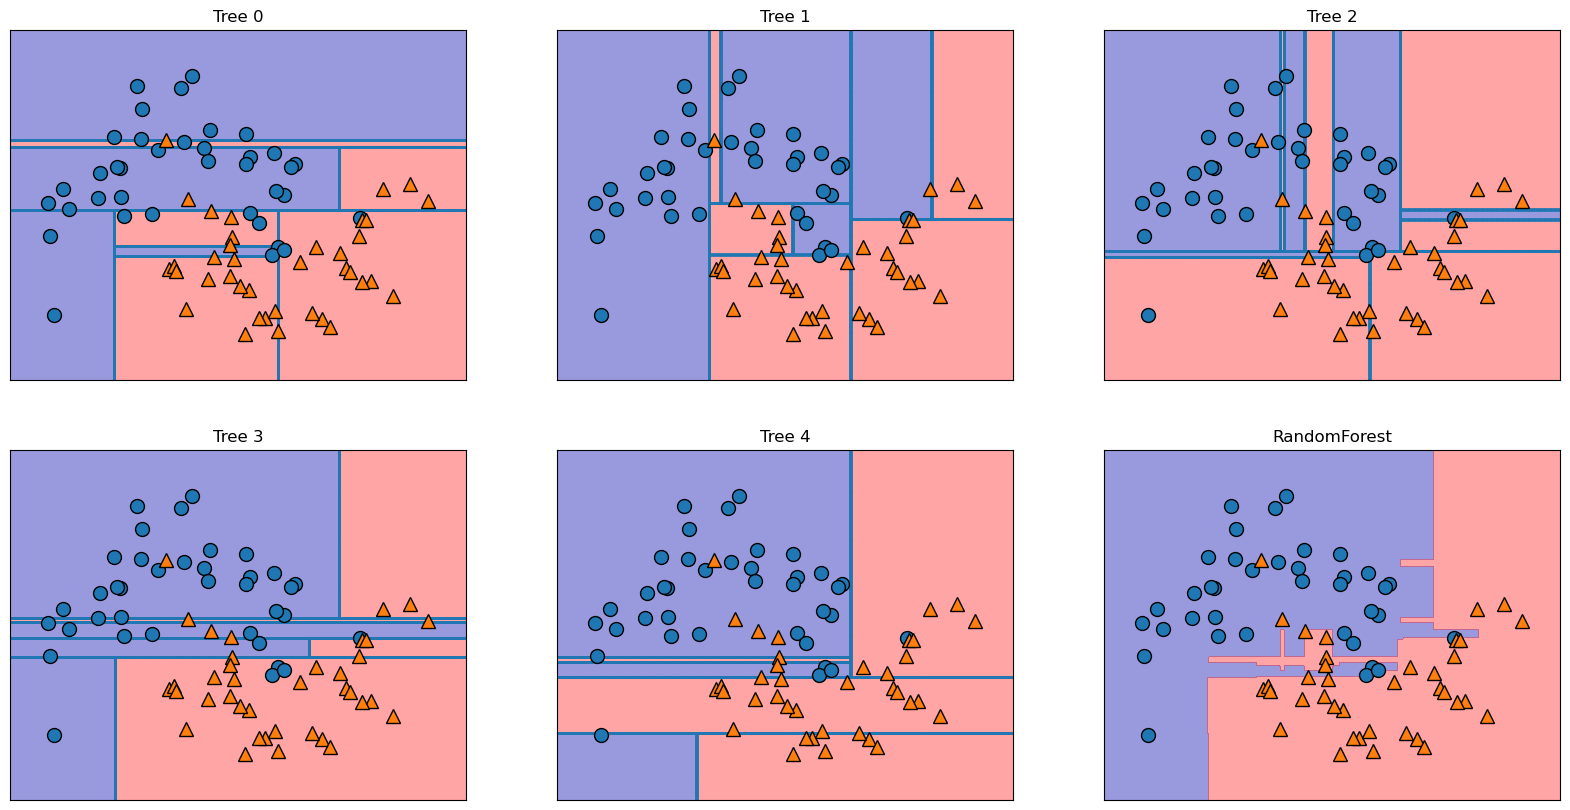

In [20]:
fig,axes = plt.subplots(2,3,figsize=(20,10))
for i,(ax,tree) in enumerate(zip(axes.ravel(),forest.estimators_)):
    ax.set_title(f"Tree {i}")
    mglearn.plots.plot_tree_partition(X_train,y_train,tree,ax=ax)
mglearn.plots.plot_2d_separator(forest,X_train,fill=True,ax=axes[-1,-1],alpha=0.4)
axes[-1,-1].set_title("RandomForest")
mglearn.discrete_scatter(X_train[:,0],X_train[:,1],y_train)

In [21]:
X_train,X_test,y_train,y_test = train_test_split(cancer.data,cancer.target,random_state=0)
forest = RandomForestClassifier(n_estimators=100,random_state=0)
forest.fit(X_train,y_train)
print(f"Accuracy on training set:{forest.score(X_train,y_train)}")
print(f"Accuracy on test set:{forest.score(X_test,y_test)}")

Accuracy on training set:1.0
Accuracy on test set:0.972027972027972


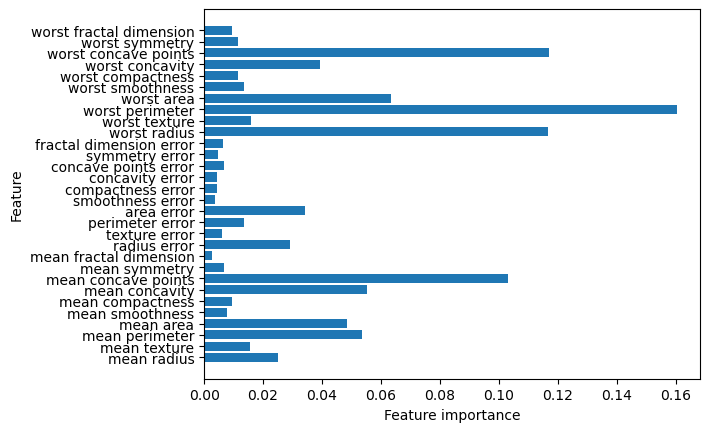

In [22]:
plot_feature_importances_cancer(forest)

In [23]:
from sklearn.ensemble import GradientBoostingClassifier
X_train,X_test,y_train,y_test = train_test_split(cancer.data,cancer.target,random_state=0)
gbrt = GradientBoostingClassifier(random_state=0)
gbrt.fit(X_train,y_train)
print(f"Accuracy on training set:{gbrt.score(X_train,y_train)}")
print(f"Accuracy on test set:{gbrt.score(X_test,y_test)}")

Accuracy on training set:1.0
Accuracy on test set:0.965034965034965


In [24]:
gbrt = GradientBoostingClassifier(random_state=0,max_depth=1)
gbrt.fit(X_train,y_train)
print(f"Accuracy on training set:{gbrt.score(X_train,y_train)}")
print(f"Accuracy on test set:{gbrt.score(X_test,y_test)}")

Accuracy on training set:0.9906103286384976
Accuracy on test set:0.972027972027972


In [25]:
gbrt = GradientBoostingClassifier(random_state=0,learning_rate=0.01)
gbrt.fit(X_train,y_train)
print(f"Accuracy on training set:{gbrt.score(X_train,y_train)}")
print(f"Accuracy on test set:{gbrt.score(X_test,y_test)}")

Accuracy on training set:0.9882629107981221
Accuracy on test set:0.958041958041958


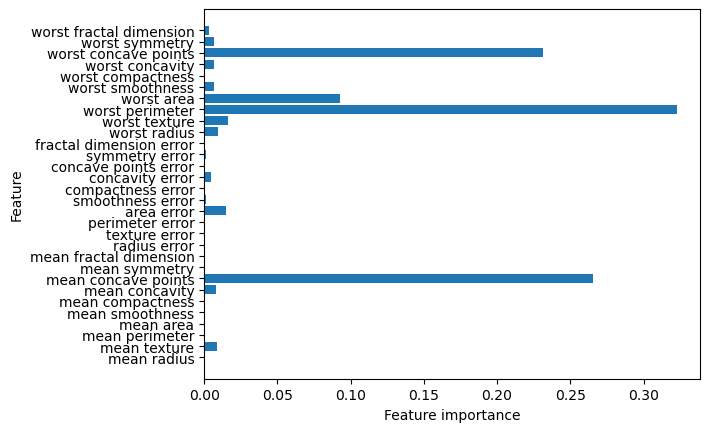

In [26]:
gbrt = GradientBoostingClassifier(random_state=0,max_depth=1)
gbrt.fit(X_train,y_train)
plot_feature_importances_cancer(gbrt)

Text(0, 0.5, 'Feature 1')

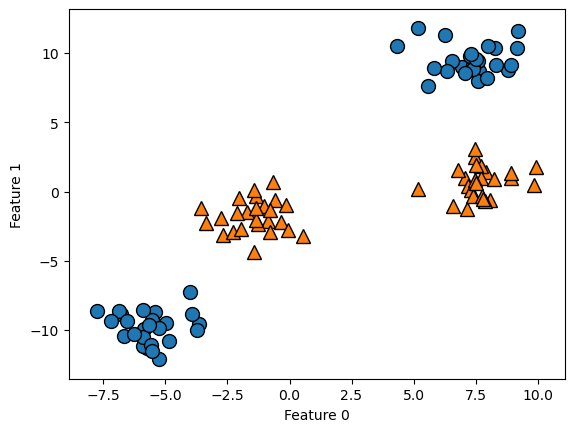

In [27]:
X,y = make_blobs(centers=4,random_state=8)
y = y%2
mglearn.discrete_scatter(X[:,0],X[:,1],y)
plt.xlabel("Feature 0")
plt.ylabel("Feature 1")

Text(0, 0.5, 'Feature 1')

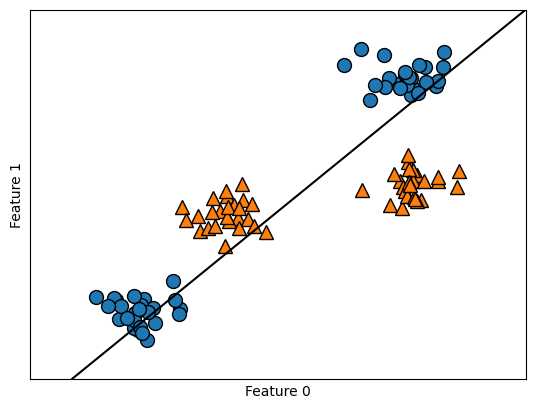

In [28]:
from sklearn.svm import LinearSVC
linear_svm = LinearSVC().fit(X,y)
mglearn.plots.plot_2d_separator(linear_svm,X)
mglearn.discrete_scatter(X[:,0],X[:,1],y)
plt.xlabel("Feature 0")
plt.ylabel("Feature 1")

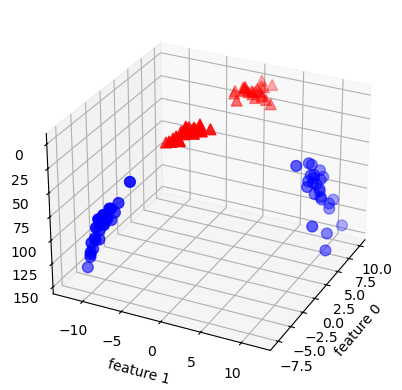

In [29]:
import matplotlib.pyplot as plt
import numpy as np

# 1. 特徴量の追加（2乗項）
X_new = np.hstack([X, X[:, 1:] ** 2])

# 2. 3Dプロット用のFigureとAxesの生成（現代的な書き方）
figure = plt.figure()
ax = figure.add_subplot(projection="3d", elev=-152, azim=-26)

mask = y == 0

# 3. 散布図の描画（cで直接指定しているため cmap を削除）
ax.scatter(X_new[mask, 0], X_new[mask, 1], X_new[mask, 2], c="b", s=60)
ax.scatter(
    X_new[~mask, 0], X_new[~mask, 1], X_new[~mask, 2], c="r", marker="^", s=60
)

# 4. ラベル設定
ax.set_xlabel("feature 0")
ax.set_ylabel("feature 1")
ax.set_zlabel("feature 1 ** 2")

plt.show()

Text(0, 0.5, 'Feature 1')

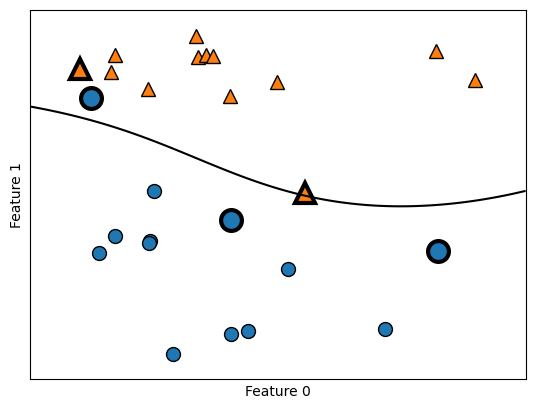

In [34]:
from sklearn.svm import SVC
X,y = mglearn.tools.make_handcrafted_dataset()
svm = SVC(kernel="rbf",C=10,gamma=0.1).fit(X,y)
mglearn.plots.plot_2d_separator(svm,X,eps=0.5)
mglearn.discrete_scatter(X[:,0],X[:,1],y)
sv = svm.support_vectors_
sv_labels = svm.dual_coef_.ravel() > 0
mglearn.discrete_scatter(sv[:,0],sv[:,1],sv_labels,s=15,markeredgewidth=3)
plt.xlabel("Feature 0")
plt.ylabel("Feature 1")

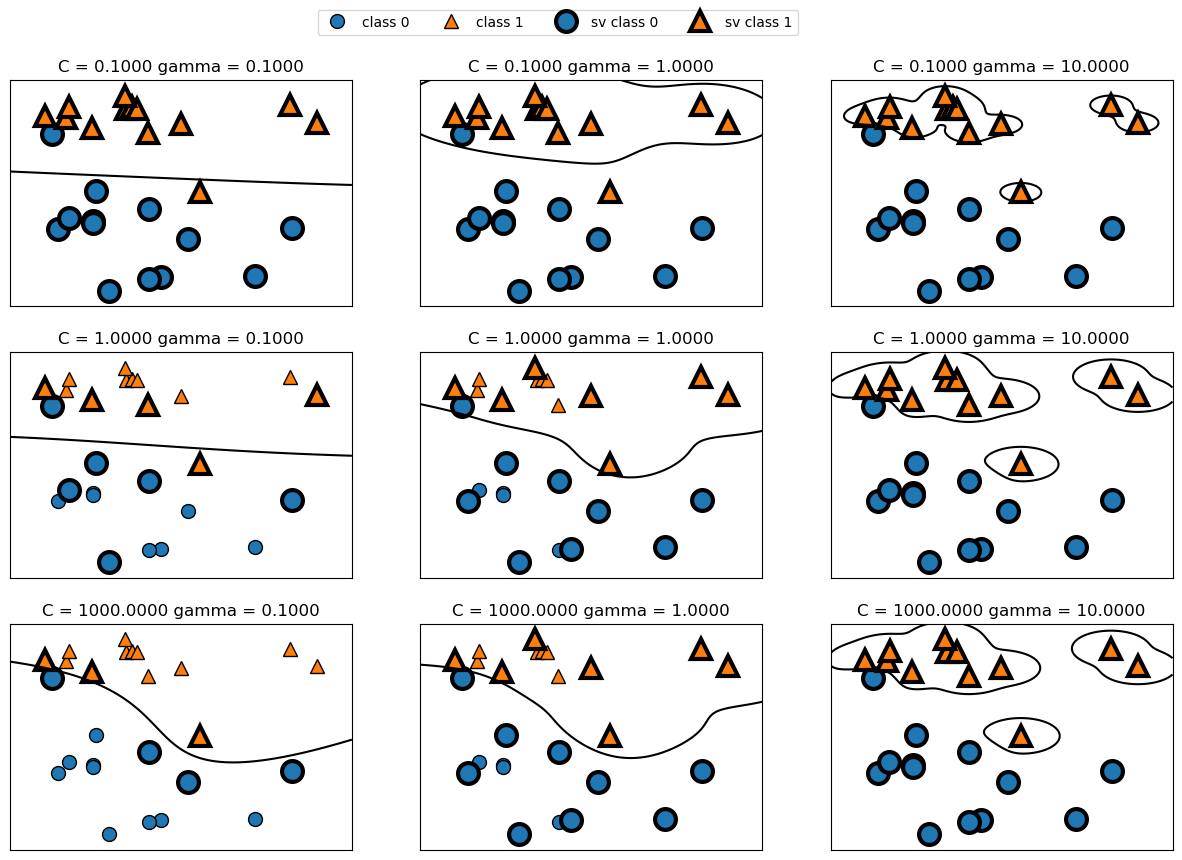

In [31]:
fig,axes = plt.subplots(3,3,figsize=(15,10))

for ax,C in zip(axes,[-1,0,3]):
    for a,gamma in zip(ax,range(-1,2)):
        mglearn.plots.plot_svm(log_C=C,log_gamma = gamma,ax=a)
axes[0,0].legend(["class 0","class 1","sv class 0","sv class 1"],ncol=4,loc=(0.9,1.2))

In [32]:
X_train,X_test,y_train,y_test = train_test_split(cancer.data,cancer.target,random_state=0)
svc = SVC()
svc.fit(X_train,y_train)
print(f"training set accuracy:{svc.score(X_train,y_train)}")
print(f"test set accuracy:{svc.score(X_test,y_test)}")

training set accuracy:0.903755868544601
test set accuracy:0.9370629370629371


Text(0, 0.5, 'Feature magnitude')

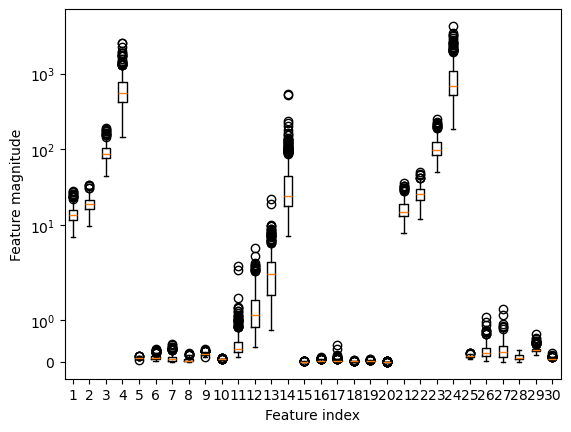

In [35]:
plt.boxplot(X_train)
plt.yscale("symlog")
plt.xlabel("Feature index")
plt.ylabel("Feature magnitude")

In [36]:
min_on_training = X_train.min(axis=0)
range_on_training = (X_train - min_on_training).max(axis=0)
X_train_scaled = (X_train - min_on_training)/range_on_training
print(f"mininum for each feature:{X_train_scaled.min(axis=0)}")
print(f"maxinum for each feature:{X_train_scaled.max(axis=0)}")

mininum for each feature:[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0.]
maxinum for each feature:[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1.]


In [38]:
X_test_scaled = (X_test - min_on_training)/range_on_training
svc.fit(X_train_scaled,y_train)
print(f"Accuracy on training set:{svc.score(X_train_scaled,y_train)}")
print(f"Accuracy on test set:{svc.score(X_test_scaled,y_test)}")

Accuracy on training set:0.9835680751173709
Accuracy on test set:0.972027972027972


In [40]:
svc = SVC(C=1000)
svc.fit(X_train,y_train)
print(f"Accuracy on training set:{svc.score(X_train_scaled,y_train)}")
print(f"Accuracy on test set:{svc.score(X_test_scaled,y_test)}")

Accuracy on training set:0.6267605633802817
Accuracy on test set:0.6293706293706294
